<a href="https://colab.research.google.com/github/DanielYaari28/AIPI510P1/blob/daniel-final-ranking/notebooks/03_final_ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import pandas as pd

url = "https://raw.githubusercontent.com/DanielYaari28/AIPI510P1/refs/heads/main/data/engineered_college_data.csv"
df = pd.read_csv(url)

In [76]:
df.columns

Index(['UNITID', 'INSTNM', 'STABBR', 'CONTROL', 'UGDS', 'C150_4', 'RET_FT4',
       'NPT4_PUB', 'NPT4_PRIV', 'DEBT_MDN', 'COSTT4_A', 'MD_EARN_WNE_P10',
       'PCTPELL', 'ADM_RATE', 'NET_PRICE', 'STUDENT_SUCCESS',
       'DEBT_TO_EARNINGS', 'EARNINGS_PERCENTILE', 'DEBT_BURDEN_PERCENTILE',
       'OUTCOME_SCORE', 'AFFORDABILITY_PERCENTILE',
       'ACCESSIBILITY_PERCENTILE'],
      dtype='object')

In [77]:
df["STUDENT_SUCCESS_PERCENTILE"] = df["STUDENT_SUCCESS"].rank(
    pct=True,
    ascending=True
)

In [78]:
df["FINAL_SCORE"] = (
    df["STUDENT_SUCCESS_PERCENTILE"] * 0.40
    + df["OUTCOME_SCORE"] * 0.35
    + df["AFFORDABILITY_PERCENTILE"] * 0.20
    + df["ACCESSIBILITY_PERCENTILE"] * 0.05
)

In [79]:
final_ranking = (
    df
    .sort_values("FINAL_SCORE", ascending=False)
    .head(10)
    [[
        "INSTNM",
        "STUDENT_SUCCESS_PERCENTILE",
        "OUTCOME_SCORE",
        "AFFORDABILITY_PERCENTILE",
        "ACCESSIBILITY_PERCENTILE",
        "FINAL_SCORE"
    ]]
)

final_ranking

,INSTNM,STUDENT_SUCCESS_PERCENTILE,OUTCOME_SCORE,AFFORDABILITY_PERCENTILE,ACCESSIBILITY_PERCENTILE,FINAL_SCORE
393,Princeton University,1.000000,0.993804,0.971499,0.198265,0.952045
48,University of California-Berkeley,0.967782,0.968030,0.753408,0.455390,0.899374
51,University of California-Los Angeles,0.969021,0.919207,0.811029,0.442379,0.893656
760,Stanford University,0.966543,0.998513,0.737299,0.195787,0.893346
655,Rice University,0.982652,0.963073,0.760843,0.136307,0.889120
146,Georgia Institute of Technology-Main Campus,0.978934,0.935316,0.830235,0.057001,0.887831
53,University of California-San Diego,0.914498,0.922181,0.814126,0.603470,0.881561
122,University of Florida,0.962825,0.823916,0.970260,0.270136,0.881059
172,University of Chicago,0.993804,0.959851,0.684015,0.091698,0.874857
50,University of California-Irvine,0.924411,0.905328,0.713755,0.651797,0.861970


In [80]:
final_ranking = final_ranking.reset_index(drop=True)

final_ranking.index = final_ranking.index + 1

final_ranking.index.name = "RANK"

final_ranking

,INSTNM,STUDENT_SUCCESS_PERCENTILE,OUTCOME_SCORE,AFFORDABILITY_PERCENTILE,ACCESSIBILITY_PERCENTILE,FINAL_SCORE
RANK,,,,,,
1,Princeton University,1.000000,0.993804,0.971499,0.198265,0.952045
2,University of California-Berkeley,0.967782,0.968030,0.753408,0.455390,0.899374
3,University of California-Los Angeles,0.969021,0.919207,0.811029,0.442379,0.893656
4,Stanford University,0.966543,0.998513,0.737299,0.195787,0.893346
5,Rice University,0.982652,0.963073,0.760843,0.136307,0.889120
6,Georgia Institute of Technology-Main Campus,0.978934,0.935316,0.830235,0.057001,0.887831
7,University of California-San Diego,0.914498,0.922181,0.814126,0.603470,0.881561
8,University of Florida,0.962825,0.823916,0.970260,0.270136,0.881059
9,University of Chicago,0.993804,0.959851,0.684015,0.091698,0.874857


TO verify, I will change the weights to ensure nothing out of the ordinary comes up.

In [81]:
scenarios = {
    "baseline": [0.4, 0.35, 0.2, 0.05],
    "equal": [0.25, 0.25, 0.25, 0.25],
    "success": [0.7, 0.2, 0.05, 0.05],
    "outcome": [0.3, 0.45, 0.15, 0.1],
    "affordability": [0.3, 0.2, 0.4, 0.1],
    "accessibility": [0.2, 0.2, 0.2, 0.4]
}

for name, weights in scenarios.items():
  df[name] = (
    df["STUDENT_SUCCESS_PERCENTILE"] * weights[0]
    + df["OUTCOME_SCORE"] * weights[1]
    + df["AFFORDABILITY_PERCENTILE"] * weights[2]
    + df["ACCESSIBILITY_PERCENTILE"] * weights[3]
  )


In [82]:
baseline = (df.sort_values(
    "baseline", ascending = False
    ).head(10)[[
        "INSTNM",
        "STUDENT_SUCCESS_PERCENTILE",
        "OUTCOME_SCORE",
        "AFFORDABILITY_PERCENTILE",
        "ACCESSIBILITY_PERCENTILE",
        "baseline",
    ]]
    )

baseline

,INSTNM,STUDENT_SUCCESS_PERCENTILE,OUTCOME_SCORE,AFFORDABILITY_PERCENTILE,ACCESSIBILITY_PERCENTILE,baseline
393,Princeton University,1.000000,0.993804,0.971499,0.198265,0.952045
48,University of California-Berkeley,0.967782,0.968030,0.753408,0.455390,0.899374
51,University of California-Los Angeles,0.969021,0.919207,0.811029,0.442379,0.893656
760,Stanford University,0.966543,0.998513,0.737299,0.195787,0.893346
655,Rice University,0.982652,0.963073,0.760843,0.136307,0.889120
146,Georgia Institute of Technology-Main Campus,0.978934,0.935316,0.830235,0.057001,0.887831
53,University of California-San Diego,0.914498,0.922181,0.814126,0.603470,0.881561
122,University of Florida,0.962825,0.823916,0.970260,0.270136,0.881059
172,University of Chicago,0.993804,0.959851,0.684015,0.091698,0.874857
50,University of California-Irvine,0.924411,0.905328,0.713755,0.651797,0.861970


In [83]:
equal = (df.sort_values(
    "equal", ascending = False
    ).head(10)[[
        "INSTNM",
        "STUDENT_SUCCESS_PERCENTILE",
        "OUTCOME_SCORE",
        "AFFORDABILITY_PERCENTILE",
        "ACCESSIBILITY_PERCENTILE",
        "equal",
    ]]
    )

equal

,INSTNM,STUDENT_SUCCESS_PERCENTILE,OUTCOME_SCORE,AFFORDABILITY_PERCENTILE,ACCESSIBILITY_PERCENTILE,equal
416,CUNY Bernard M Baruch College,0.745973,0.904089,0.998761,0.919455,0.892069
42,California State University-Fullerton,0.696406,0.747955,0.969021,0.850062,0.815861
53,University of California-San Diego,0.914498,0.922181,0.814126,0.603470,0.813569
44,California State University-Long Beach,0.705081,0.774226,0.887237,0.869888,0.809108
38,California State Polytechnic University-Pomona,0.702602,0.836927,0.853779,0.836431,0.807435
419,CUNY City College,0.464684,0.820322,0.992565,0.934325,0.802974
780,University of California-Merced,0.669145,0.762330,0.836431,0.930607,0.799628
50,University of California-Irvine,0.924411,0.905328,0.713755,0.651797,0.798823
393,Princeton University,1.000000,0.993804,0.971499,0.198265,0.790892
420,CUNY Hunter College,0.448575,0.788104,1.000000,0.912020,0.787175


In [84]:
success = (df.sort_values(
    "success", ascending = False
    ).head(10)[[
        "INSTNM",
        "STUDENT_SUCCESS_PERCENTILE",
        "OUTCOME_SCORE",
        "AFFORDABILITY_PERCENTILE",
        "ACCESSIBILITY_PERCENTILE",
        "success",
    ]]
    )

success

,INSTNM,STUDENT_SUCCESS_PERCENTILE,OUTCOME_SCORE,AFFORDABILITY_PERCENTILE,ACCESSIBILITY_PERCENTILE,success
393,Princeton University,1.000000,0.993804,0.971499,0.198265,0.957249
48,University of California-Berkeley,0.967782,0.968030,0.753408,0.455390,0.931493
292,Massachusetts Institute of Technology,0.996283,0.999504,0.411400,0.200743,0.927906
172,University of Chicago,0.993804,0.959851,0.684015,0.091698,0.926419
655,Rice University,0.982652,0.963073,0.760843,0.136307,0.925328
51,University of California-Los Angeles,0.969021,0.919207,0.811029,0.442379,0.924827
286,Harvard University,0.998761,0.978934,0.454151,0.121437,0.923699
760,Stanford University,0.966543,0.998513,0.737299,0.195787,0.922937
414,Columbia University in the City of New York,0.992565,0.945229,0.368030,0.293680,0.916927
146,Georgia Institute of Technology-Main Campus,0.978934,0.935316,0.830235,0.057001,0.916679


In [85]:
outcome = (df.sort_values(
    "outcome", ascending = False
    ).head(10)[[
        "INSTNM",
        "STUDENT_SUCCESS_PERCENTILE",
        "OUTCOME_SCORE",
        "AFFORDABILITY_PERCENTILE",
        "ACCESSIBILITY_PERCENTILE",
        "outcome",
    ]]
    )

outcome

,INSTNM,STUDENT_SUCCESS_PERCENTILE,OUTCOME_SCORE,AFFORDABILITY_PERCENTILE,ACCESSIBILITY_PERCENTILE,outcome
393,Princeton University,1.000000,0.993804,0.971499,0.198265,0.912763
48,University of California-Berkeley,0.967782,0.968030,0.753408,0.455390,0.884498
416,CUNY Bernard M Baruch College,0.745973,0.904089,0.998761,0.919455,0.872392
53,University of California-San Diego,0.914498,0.922181,0.814126,0.603470,0.871797
51,University of California-Los Angeles,0.969021,0.919207,0.811029,0.442379,0.870242
760,Stanford University,0.966543,0.998513,0.737299,0.195787,0.869467
50,University of California-Irvine,0.924411,0.905328,0.713755,0.651797,0.856964
655,Rice University,0.982652,0.963073,0.760843,0.136307,0.855936
146,Georgia Institute of Technology-Main Campus,0.978934,0.935316,0.830235,0.057001,0.844808
49,University of California-Davis,0.903346,0.926394,0.687732,0.526642,0.843705


In [86]:
affordability = (df.sort_values(
    "affordability", ascending = False
    ).head(10)[[
        "INSTNM",
        "STUDENT_SUCCESS_PERCENTILE",
        "OUTCOME_SCORE",
        "AFFORDABILITY_PERCENTILE",
        "ACCESSIBILITY_PERCENTILE",
        "affordability",
    ]]
    )

affordability

,INSTNM,STUDENT_SUCCESS_PERCENTILE,OUTCOME_SCORE,AFFORDABILITY_PERCENTILE,ACCESSIBILITY_PERCENTILE,affordability
393,Princeton University,1.000000,0.993804,0.971499,0.198265,0.907187
416,CUNY Bernard M Baruch College,0.745973,0.904089,0.998761,0.919455,0.896059
122,University of Florida,0.962825,0.823916,0.970260,0.270136,0.868748
799,University of Florida-Online,0.902107,0.823916,0.985130,0.280050,0.857472
53,University of California-San Diego,0.914498,0.922181,0.814126,0.603470,0.844783
51,University of California-Los Angeles,0.969021,0.919207,0.811029,0.442379,0.843197
42,California State University-Fullerton,0.696406,0.747955,0.969021,0.850062,0.831128
48,University of California-Berkeley,0.967782,0.968030,0.753408,0.455390,0.830843
488,University of North Carolina at Chapel Hill,0.957869,0.848079,0.851301,0.218092,0.819306
146,Georgia Institute of Technology-Main Campus,0.978934,0.935316,0.830235,0.057001,0.818538


In [87]:
accessibility = (df.sort_values(
    "accessibility", ascending = False
    ).head(10)[[
        "INSTNM",
        "STUDENT_SUCCESS_PERCENTILE",
        "OUTCOME_SCORE",
        "AFFORDABILITY_PERCENTILE",
        "ACCESSIBILITY_PERCENTILE",
        "accessibility",
    ]]
    )

accessibility

,INSTNM,STUDENT_SUCCESS_PERCENTILE,OUTCOME_SCORE,AFFORDABILITY_PERCENTILE,ACCESSIBILITY_PERCENTILE,accessibility
416,CUNY Bernard M Baruch College,0.745973,0.904089,0.998761,0.919455,0.897546
419,CUNY City College,0.464684,0.820322,0.992565,0.934325,0.829244
780,University of California-Merced,0.669145,0.762330,0.836431,0.930607,0.825824
42,California State University-Fullerton,0.696406,0.747955,0.969021,0.850062,0.822701
44,California State University-Long Beach,0.705081,0.774226,0.887237,0.869888,0.821264
38,California State Polytechnic University-Pomona,0.702602,0.836927,0.853779,0.836431,0.813234
420,CUNY Hunter College,0.448575,0.788104,1.000000,0.912020,0.812144
417,CUNY Brooklyn College,0.406444,0.745725,0.997522,0.921933,0.798711
41,California State University-Fresno,0.485750,0.698637,0.966543,0.920694,0.798463
421,CUNY John Jay College of Criminal Justice,0.465923,0.646592,0.995043,0.931846,0.794250


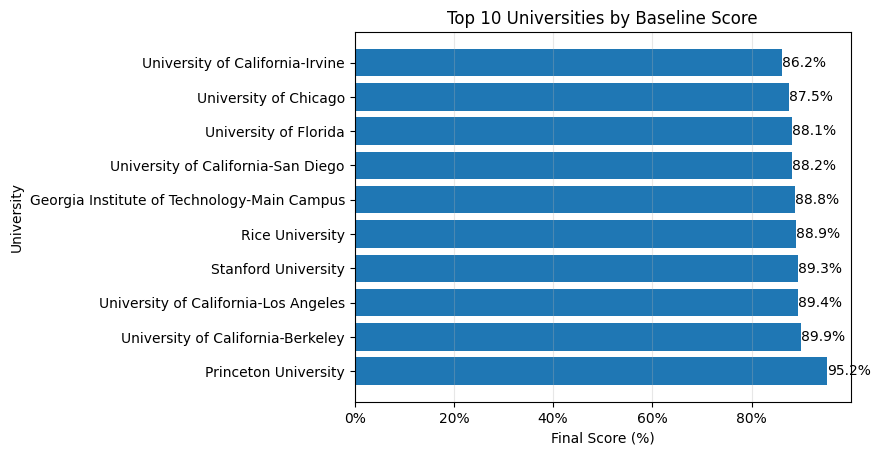

In [88]:
import matplotlib.pyplot as plt

bars = plt.barh(
    baseline["INSTNM"],
    baseline["baseline"] * 100,
    label="Baseline"
)

plt.bar_label(bars, fmt="%.1f%%")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0f}%")
)

plt.title("Top 10 Universities by Baseline Score")
plt.xlabel("Final Score (%)")
plt.ylabel("University")

plt.grid(axis="x", alpha=0.3)

plt.show()

3) Shows the ten highest-ranked universities under our baseline weighting system, combining student success, outcomes, affordability, and accessibility into one overall score.

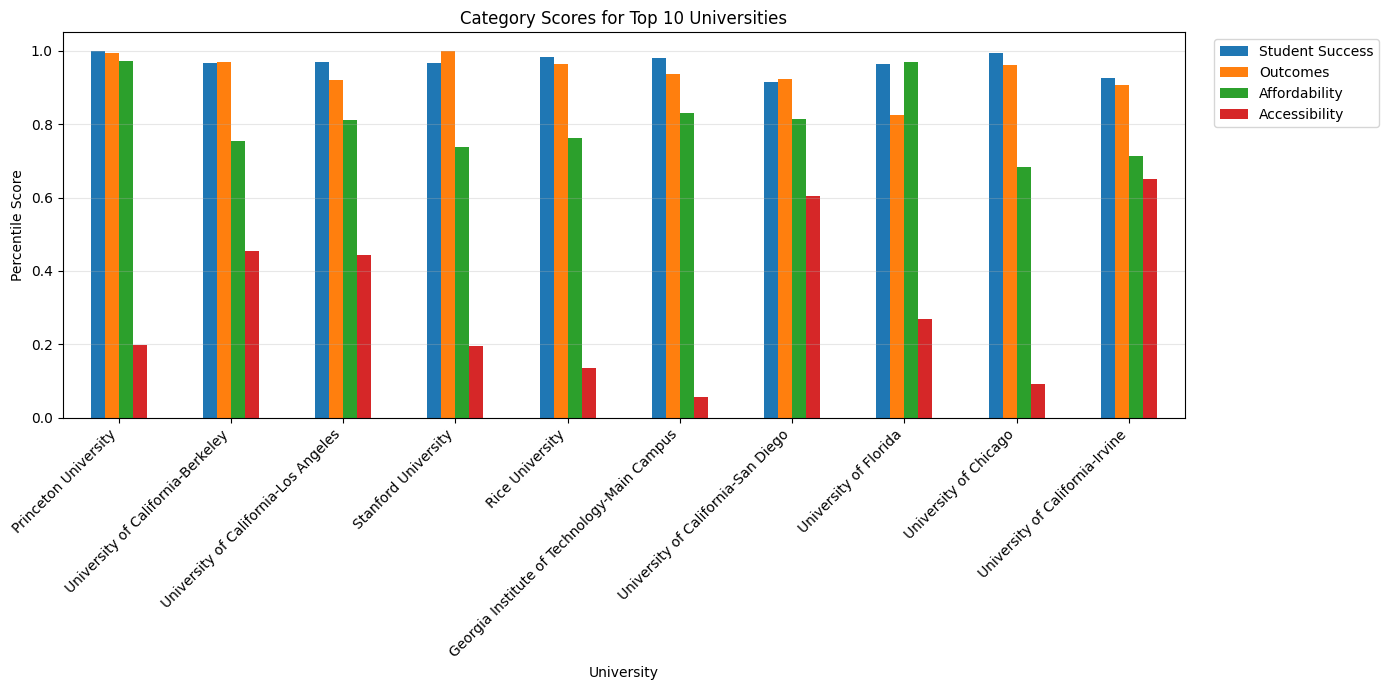

In [89]:
ax = baseline.plot(
    x="INSTNM",
    y=[
        "STUDENT_SUCCESS_PERCENTILE",
        "OUTCOME_SCORE",
        "AFFORDABILITY_PERCENTILE",
        "ACCESSIBILITY_PERCENTILE"
    ],
    kind="bar",
    figsize=(14, 7)
)

plt.title("Category Scores for Top 10 Universities")
plt.xlabel("University")
plt.ylabel("Percentile Score")

plt.xticks(rotation=45, ha="right")

plt.legend(
    ["Student Success", "Outcomes", "Affordability", "Accessibility"],
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

4) Shows how each Top 10 university performs across the four categories we decided. Shows a cool breakdown revealing the different strengths driving their overall rankings.

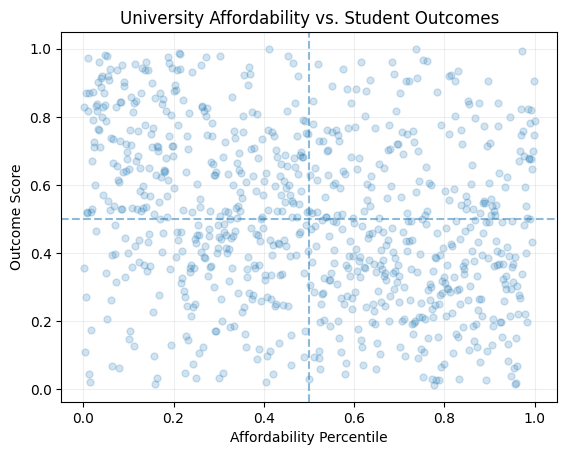

In [106]:
plt.scatter(
    df["AFFORDABILITY_PERCENTILE"],
    df["OUTCOME_SCORE"],
    alpha=0.2,
    s=25
)

plt.axvline(x=0.5, linestyle="--", alpha=0.5)
plt.axhline(y=0.5, linestyle="--", alpha=0.5)

plt.xlabel("Affordability Percentile")
plt.ylabel("Outcome Score")
plt.title("University Affordability vs. Student Outcomes")
plt.grid(alpha=0.2)

5) Shows the relationship between affordability and student outcomes across universities.

Top Right — “High Value”: Affordable, Strong Outcomes
Top Left — “Premium Performers”: Expensive, Strong Outcomes
Bottom Right — “Budget Tradeoff”: Affordable, Weaker Outcomes
Bottom Left — “Low Value”: Expensive, Weaker Outcomes

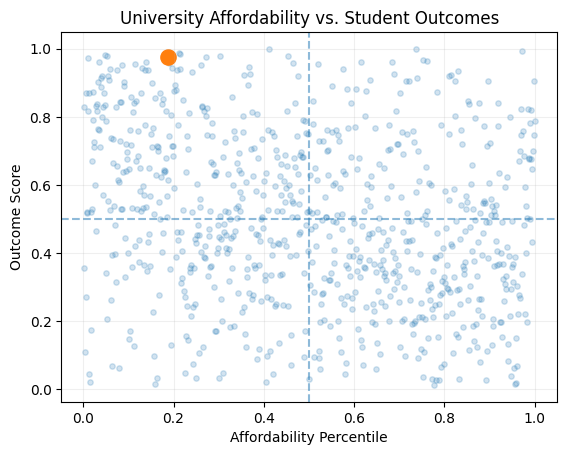

In [107]:
plt.scatter(
    df["AFFORDABILITY_PERCENTILE"],
    df["OUTCOME_SCORE"],
    alpha=0.2,
    s=15
)

plt.axvline(x=0.5, linestyle="--", alpha=0.5)
plt.axhline(y=0.5, linestyle="--", alpha=0.5)

duke_affordability = duke["AFFORDABILITY_PERCENTILE"].iloc[0]
duke_outcome = duke["OUTCOME_SCORE"].iloc[0]

plt.scatter(
    duke_affordability,
    duke_outcome,
    s=120,
    label="Duke University"
)

plt.xlabel("Affordability Percentile")
plt.ylabel("Outcome Score")
plt.title("University Affordability vs. Student Outcomes")
plt.grid(alpha=0.2)

8) This one highlights Duke.


(0.0, 1.05)

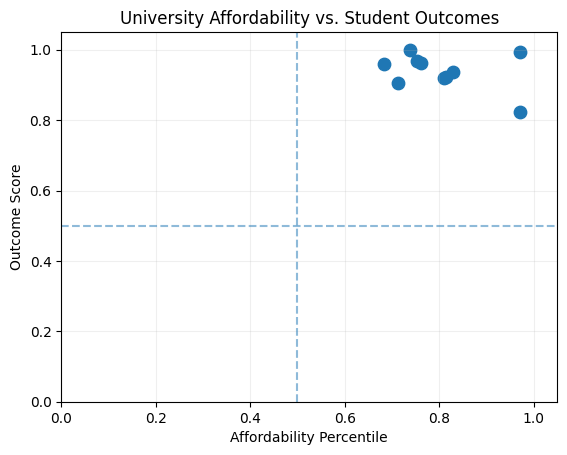

In [91]:
plt.scatter(
    baseline["AFFORDABILITY_PERCENTILE"],
    baseline["OUTCOME_SCORE"],
    s=80,
    label="Top 10"
)

plt.axvline(x=0.5, linestyle="--", alpha=0.5)
plt.axhline(y=0.5, linestyle="--", alpha=0.5)

plt.xlabel("Affordability Percentile")
plt.ylabel("Outcome Score")
plt.title("University Affordability vs. Student Outcomes")
plt.grid(alpha=0.2)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)

6) Breakdown as to where the top 10 sit.

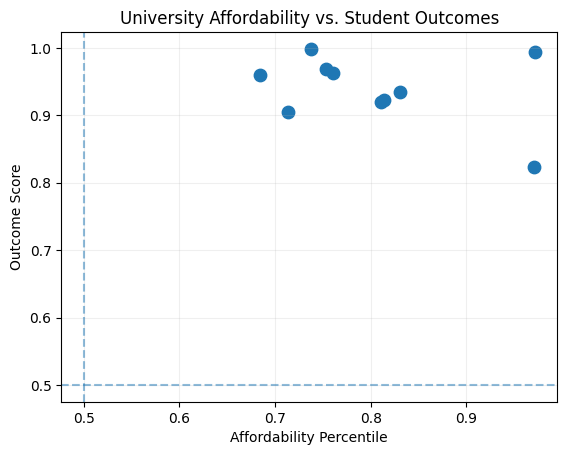

In [92]:
plt.scatter(
    baseline["AFFORDABILITY_PERCENTILE"],
    baseline["OUTCOME_SCORE"],
    s=80,
    label="Top 10"
)

plt.axvline(x=0.5, linestyle="--", alpha=0.5)
plt.axhline(y=0.5, linestyle="--", alpha=0.5)

plt.xlabel("Affordability Percentile")
plt.ylabel("Outcome Score")
plt.title("University Affordability vs. Student Outcomes")
plt.grid(alpha=0.2)

7) Zoomed in version of where the top 10 sit.

In [93]:
for name in scenarios.keys():
    df[f"{name}_rank"] = df[name].rank(
        ascending=False,
        method="min"
    )

duke = df[df["INSTNM"].str.contains("Duke", case=False)]

duke[[
    "INSTNM",
    "baseline_rank",
    "equal_rank",
    "success_rank",
    "outcome_rank",
    "affordability_rank",
    "accessibility_rank"
]]

,INSTNM,baseline_rank,equal_rank,success_rank,outcome_rank,affordability_rank,accessibility_rank
481,Duke University,39.0,207.0,19.0,41.0,180.0,505.0


Duke Case-Study of sorts could be cool to show. Shows how well Duke performs in each of the cases I did perviously.

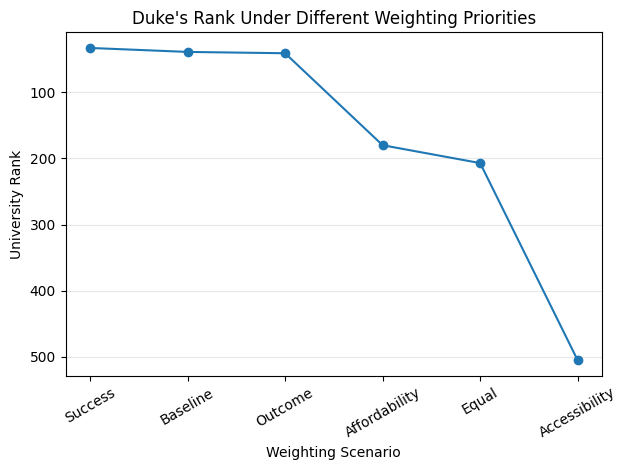

In [94]:
scenarios_names = [
    "Success",
    "Baseline",
    "Outcome",
    "Affordability",
    "Equal",
    "Accessibility"
]

duke_ranks = [
    33,
    39,
    41,
    180,
    207,
    505
]

plt.plot(
    scenarios_names,
    duke_ranks,
    marker="o"
)

plt.gca().invert_yaxis()

plt.title("Duke's Rank Under Different Weighting Priorities")
plt.xlabel("Weighting Scenario")
plt.ylabel("University Rank")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()

9) A line graph showing its performance.

/tmp/ipykernel_1052/3273368552.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


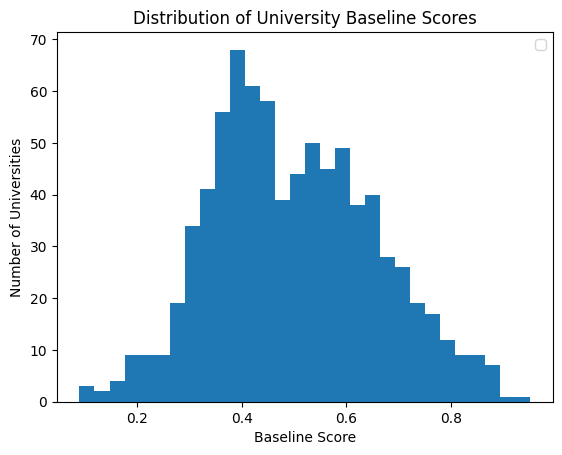

In [102]:
plt.hist(df["baseline"], bins=30)

plt.xlabel("Baseline Score")
plt.ylabel("Number of Universities")
plt.title("Distribution of University Baseline Scores")
plt.legend()
plt.show()

1) Shows how baseline scores are distributed across all universities.

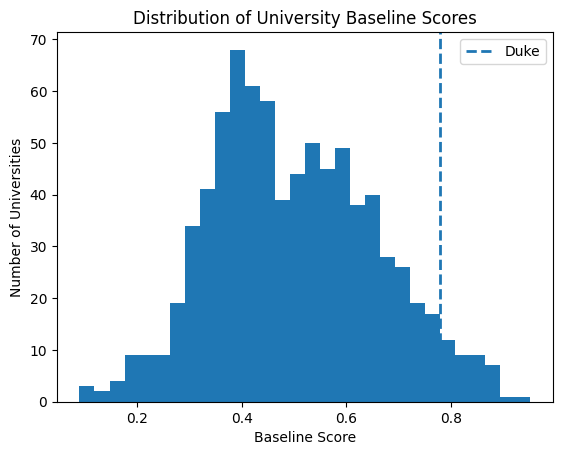

In [101]:
plt.hist(df["baseline"], bins=30)

duke_score = duke["baseline"].iloc[0]

plt.axvline(
    duke_score,
    linestyle="--",
    linewidth=2,
    label="Duke"
)

plt.xlabel("Baseline Score")
plt.ylabel("Number of Universities")
plt.title("Distribution of University Baseline Scores")
plt.legend()
plt.show()

2) This one highlights were Duke sits.